## Machine Learning - CA2.2
## Matthew Riddell - D00245674
## Albert Skalinski - D00248346

For this CA, we wish to look at doing a complex classification between fruits  
We selected the following Dataset from kaggle:

https://www.kaggle.com/datasets/utkarshsaxenadn/fruits-classification

The dataset consists of 10,000 images of the following classes

- Apples
- Bananas
- Grapes
- Mangoes
- Strawberries

### This code will also be uploaded to our github repo here:

https://github.com/Matthew-Riddell/Machine-Learning-CA3


#### Package Imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

#### Dataset folders

In [2]:
## Matthew's folder: "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Machine Learning/CAs/CA3/Machine-Learning-CA3/dataset/"
## Albert's folder: "Comment here ur folder so you can swap back after commits"

datasets_folder = "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Machine Learning/CAs/CA3/Machine-Learning-CA3/dataset/"
train_folder = datasets_folder + "training_set/training_set/"
test_folder = datasets_folder + "test_set/test_set/"

#### Loading the dataset and dividing the images into batches

loads the images from the folders and keras applies labels

resizes the images to 128x128 and takes them in batches of 32 images at a time

image_dataset_from_directory() then returns the count of x (images) and y (classes) which are apple, banana, grape, mango and strawberry

In [3]:
# https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_folder,
    image_size=(128, 128),
    batch_size=32
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_folder,
    image_size=(128, 128),
    batch_size=32
)

Found 9700 files belonging to 5 classes.
Found 100 files belonging to 5 classes.


#### Normalization

rescaling the pixels to be values between 0 and 1 so they work better in the neural network

the normalization is then applied to each image in the datasets via the x (image) and y (class) values 

In [4]:
# https://www.tensorflow.org/api_docs/python/tf/keras/layers/Rescaling

normalization = layers.Rescaling(1./255)
train_data = train_data.map(lambda x, y: (normalization(x), y))
test_data = test_data.map(lambda x, y: (normalization(x), y))

## Simple Machine Learning Models

### Baseline CNN Model

#### Making the CNN Model

here a simple sequential CNN model is made:

Input layer -> Convolutional Layer 1 -> Pooling Layer 1 -> Convolutional Layer 2 -> Pooling Layer 2 -> Flatten Layer -> Dense Layer -> Output Layer

The convolutional layers will use the ReLu activation function which outputs a 1 for positive inputs and 0 for negatives 

The final layer will use the softmax activation function which is the ideal activation function for multiple classes in a classification problem 



In [5]:
# https://www.tensorflow.org/guide/keras/sequential_model?hl=en

model1 = Sequential()

# Convolutional Layer 1
model1.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

# Pooling Layer 1
model1.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Layer 2
model1.add(Conv2D(64, (3,3), activation='relu'))

# Pooling Layer 2
model1.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model1.add(Flatten())

# Dense Layer
model1.add(Dense(64, activation='relu'))

# Output Layer
model1.add(Dense(5, activation='softmax'))

c:\Users\Matty\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Model Shape and Size

In [6]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,181 (14.14 MB)

 Trainable params: 3,706,181 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the Model

preparing the model for training using the adam optimizer and using sparse cetegorical cross entropy as the loss function since it is a a multiple categorical classification

In [7]:
# https://www.tensorflow.org/api_docs/python/tf/keras/Model
# https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Training the Model

In [8]:
history1 = model1.fit(train_data, epochs=25)

Epoch 1/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 71s 227ms/step - accuracy: 0.4601 - loss: 1.2748
Epoch 2/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 74s 243ms/step - accuracy: 0.5969 - loss: 1.0067
Epoch 3/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 70s 231ms/step - accuracy: 0.6755 - loss: 0.8260
Epoch 4/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 71s 232ms/step - accuracy: 0.7629 - loss: 0.6361
Epoch 5/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 133s 438ms/step - accuracy: 0.8448 - loss: 0.4313
Epoch 6/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 70s 231ms/step - accuracy: 0.9140 - loss: 0.2541
Epoch 7/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 74s 242ms/step - accuracy: 0.9454 - loss: 0.1706
Epoch 8/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 75s 246ms/step - accuracy: 0.9621 - loss: 0.1252
Epoch 9/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 74s 244ms/step - accuracy: 0.9763 - loss: 0.0780
Epoch 10/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 125s 412ms/step - accuracy: 0.9780 - loss: 0.0704
Epoch 11/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 71s 233ms/step - accuracy: 0.9846 - loss: 0.0534
Epoch 12/25
304/3

#### Testing and Evaluation based on Test Data

In [9]:
loss, acc = model1.evaluate(test_data)
print("Test accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6200 - loss: 3.4271
Test accuracy: 0.6200000047683716


accuracy: 0.6200 - loss: 3.4271

average performance for this simple CNN

it is basically correct 62% of the time

### Expanded CNN Model

#### Making the CNN Model

this model has an extra 3rd convolutional and pooling layer

here an expanded sequential CNN model is made:

Input layer -> Convolutional Layer 1 -> Pooling Layer 1 -> Convolutional Layer 2 -> Pooling Layer 2 -> Convolutional Layer 3 -> Pooling Layer 3 -> Flatten Layer -> Dense Layer -> Output Layer

The convolutional layers will use the ReLu activation function which outputs a 1 for positive inputs and 0 for negatives 

The final layer will use the softmax activation function which is the ideal activation function for multiple classes in a classification problem 



In [10]:
# https://www.tensorflow.org/guide/keras/sequential_model?hl=en

model2 = Sequential()

# Convolutional Layer 1
model2.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))

# Pooling Layer 1
model2.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Layer 2
model2.add(Conv2D(64, (3,3), activation='relu'))

# Pooling Layer 2
model2.add(MaxPooling2D(pool_size=(2,2)))

# Convolutional Layer 3
model2.add(Conv2D(128, (3,3), activation='relu'))

# Pooling Layer 3
model2.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model2.add(Flatten())

# Dense Layer
model2.add(Dense(64, activation='relu'))

# Output Layer
model2.add(Dense(5, activation='softmax'))

#### Model Shape and Size

In [11]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,269 (6.48 MB)

 Trainable params: 1,699,269 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

#### Compiling the model 

In [12]:
# https://www.tensorflow.org/api_docs/python/tf/keras/Model
# https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Training the model

In [13]:
history2 = model2.fit(train_data, epochs=25)

Epoch 1/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 95s 308ms/step - accuracy: 0.5003 - loss: 1.1718
Epoch 2/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 85s 281ms/step - accuracy: 0.6021 - loss: 0.9708
Epoch 3/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 84s 277ms/step - accuracy: 0.6555 - loss: 0.8613
Epoch 4/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 87s 286ms/step - accuracy: 0.7062 - loss: 0.7524
Epoch 5/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 90s 295ms/step - accuracy: 0.7540 - loss: 0.6428
Epoch 6/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 91s 300ms/step - accuracy: 0.8061 - loss: 0.5069
Epoch 7/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 92s 301ms/step - accuracy: 0.8624 - loss: 0.3708
Epoch 8/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 97s 319ms/step - accuracy: 0.9057 - loss: 0.2670
Epoch 9/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 92s 301ms/step - accuracy: 0.9278 - loss: 0.2067
Epoch 10/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 94s 307ms/step - accuracy: 0.9484 - loss: 0.1483
Epoch 11/25
304/304 ━━━━━━━━━━━━━━━━━━━━ 94s 308ms/step - accuracy: 0.9638 - loss: 0.1131
Epoch 12/25
304/304

#### Testing and Evaluation of model on test data

In [14]:
loss, acc = model2.evaluate(test_data)
print("Test accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.6500 - loss: 3.2067
Test accuracy: 0.6499999761581421


accuracy: 0.6500 - loss: 3.2067

average performance for this extended CNN model

it is basically correct 65% of the time

compared to the first model this is a very slight improvment

### Comparing the accuracy of Both Models

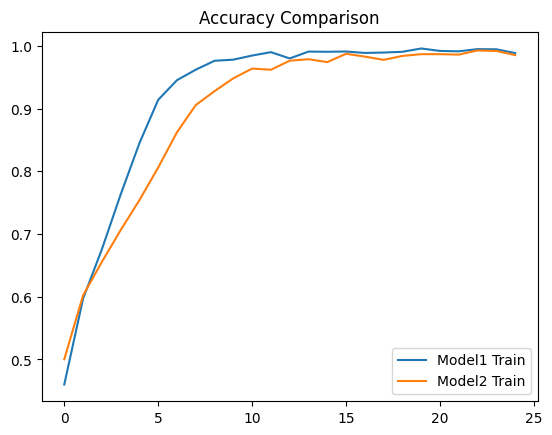

In [18]:
plt.plot(history1.history['accuracy'], label='Model1 Train')
plt.plot(history2.history['accuracy'], label='Model2 Train')

plt.legend()
plt.title("Accuracy Comparison")
plt.show()

## Complex Machine Learning Models